<a href="https://colab.research.google.com/github/sigvehaug/MLwPython/blob/master/course_1_accdata_HKB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# About this Introduction to the Winter School on Deep Learning

An introduction on how to perform typical machine learning tasks with Python.

PD Dr. Sigve Haug, 2025. https://github.com/sigvehaug/MLwPython

This work is licensed under <a href="https://creativecommons.org/share-your-work/public-domain/cc0/">CC0</a>.

Duration: 45 min


## Load and inspect dataset (exploratory data analysis)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls -l drive/MyDrive/Courses/

Take a look at the dataset with excel or google sheets.

In [3]:
!ls -l ./drive/MyDrive/Courses/WS-DL-2024/

total 7713
-rw------- 1 root root  179714 Feb 26  2024  boxing.csv
-rw------- 1 root root  516549 Feb 26  2024  BWS-2024-ML-Refresher.ipynb
-rw------- 1 root root     175 Feb 28  2025  BWSDL-2024-Feedback.gform
-rw------- 1 root root     175 Feb 12  2024  BWS-DL-2024-Projects.gdoc
-rw------- 1 root root     175 Feb 28  2025  BWSDL-2025-Feedback.gform
-rw------- 1 root root  294640 Jan 14  2024  BWSML-DL-FB-2024.pdf
-rw------- 1 root root  267578 Jan  5  2024  Data-Jump.csv
-rw------- 1 root root  252899 Jan  5  2024  Data-Walk.csv
-rw------- 1 root root 4050049 Mar 27  2024  Lecture2_MV_2024.pdf
-rw------- 1 root root     175 Feb 26  2024  ML-Brushup-BWSML-24.gslides
-rw------- 1 root root 1983421 Jan  3  2024 'movement 1.ipynb'
-rw------- 1 root root  347370 Feb 26  2024  walk.csv
-rw------- 1 root root     175 Jan  5  2024  WS-DL-Classification-Champion.gform
-rw------- 1 root root     175 Mar 13  2024  WS-NLP-FB-2024.gform
-rw------- 1 root root     175 Mar  1  2024  WS-RL-FB-2024.g

In [3]:
import pandas as pd
dataset1 = './drive/MyDrive/Courses/WS-DL-2024/Data-Walk.csv'
dataset2 = './drive/MyDrive/Courses/WS-DL-2024/Data-Jump.csv'

movement1 = pd.read_csv(dataset1)
movement2 = pd.read_csv(dataset2)

# Add the category column "type" for data labeling

movement1['type'] = 'walk'
movement2['type'] = 'jump'

movement = pd.concat([movement1, movement2])
movement

,Time (s),Linear Acceleration x (m/s^2),Linear Acceleration y (m/s^2),Linear Acceleration z (m/s^2),Absolute acceleration (m/s^2),type
0,0.008433,-0.439448,0.298613,-0.266528,0.594408,walk
1,0.018430,-0.593483,0.407320,-0.078499,0.724081,walk
2,0.028427,-0.642879,0.395847,-0.045668,0.756356,walk
3,0.038424,-0.582221,0.375405,-0.089089,0.698460,walk
4,0.048420,-0.449434,0.322077,-0.263234,0.612386,walk
...,...,...,...,...,...,...
3717,37.161753,-0.932274,-0.165263,0.062793,0.948889,jump
3718,37.171750,-0.600473,-0.040368,0.082966,0.607520,jump
3719,37.181747,-0.401486,0.058877,0.134857,0.427603,jump
3720,37.191744,-0.362165,0.068498,0.100655,0.382083,jump


In [ ]:
movement.info()

In [ ]:
movement[movement['type']=='walk'].describe()

In [ ]:
movement[movement['type']=='jump'].describe()

### Visualize

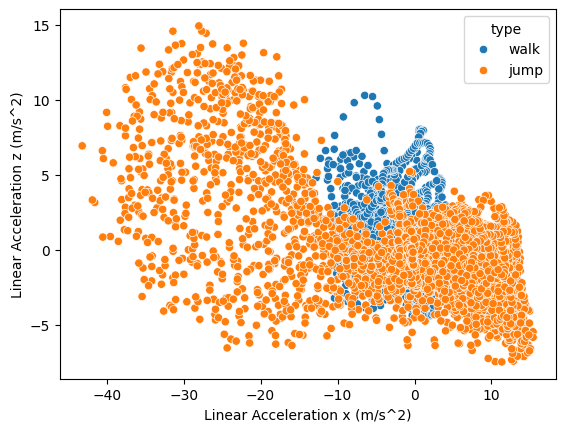

In [4]:
import seaborn as sns
sns.scatterplot(data=movement, x='Linear Acceleration x (m/s^2)',
                y='Linear Acceleration z (m/s^2)', hue='type');

In [ ]:
sns.scatterplot(data=movement, x='Linear Acceleration x (m/s^2)',
                y='Linear Acceleration y (m/s^2)', hue='type');

In [ ]:
sns.scatterplot(data=movement, x='Linear Acceleration y (m/s^2)',
                y='Linear Acceleration z (m/s^2)', hue='type');

Return to slides !

### Clean and split the data

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

In [6]:
training = movement.drop(columns=['Time (s)'])
train, test = train_test_split(training, train_size=0.8)
print(train.shape, test.shape)
train

(5768, 5) (1442, 5)


,Linear Acceleration x (m/s^2),Linear Acceleration y (m/s^2),Linear Acceleration z (m/s^2),Absolute acceleration (m/s^2),type
1408,4.770049,8.913503,-0.790788,10.140476,jump
567,7.458383,3.628909,2.216156,8.585324,jump
1399,8.223066,8.212428,-2.635080,11.916646,jump
3223,-8.785942,-3.873698,2.997016,10.058848,walk
1160,8.787755,4.023803,-0.055593,9.665336,jump
...,...,...,...,...,...
2105,-3.648499,5.723677,-1.513697,6.954373,walk
1779,0.624528,0.500066,-1.362473,1.580011,walk
2595,6.350942,5.664131,1.341064,8.614830,jump
260,-1.222674,5.465305,0.347981,5.611201,walk


## Train and Evaluate Models

Here we try two different models and check for overfitting.

In [7]:
x_train   = train.drop(columns='type')
y_train   = train['type']

x_test   = test.drop(columns='type')
y_test   = test['type']

#Chose and train the model
model = LogisticRegression()
#model = RandomForestClassifier(max_depth=12, random_state=0)
model.fit(x_train, y_train)

LogisticRegression()

In [8]:
model.predict(x_train)

array(['jump', 'jump', 'jump', ..., 'jump', 'walk', 'walk'], dtype=object)

In [9]:
print('Performance of the inference on the training set')
print(confusion_matrix(y_train,model.predict(x_train)))
print(classification_report(y_train, model.predict(x_train)))

Performance of the inference on the training set
[[2303  702]
 [ 356 2407]]
              precision    recall  f1-score   support

        jump       0.87      0.77      0.81      3005
        walk       0.77      0.87      0.82      2763

    accuracy                           0.82      5768
   macro avg       0.82      0.82      0.82      5768
weighted avg       0.82      0.82      0.82      5768



In [10]:
print('Performance of the inference on the test set')
print(confusion_matrix(y_test, model.predict(x_test)))
print(classification_report(y_test, model.predict(x_test)))

Performance of the inference on the test set
[[541 176]
 [ 94 631]]
              precision    recall  f1-score   support

        jump       0.85      0.75      0.80       717
        walk       0.78      0.87      0.82       725

    accuracy                           0.81      1442
   macro avg       0.82      0.81      0.81      1442
weighted avg       0.82      0.81      0.81      1442



If we have time (I don't think we will have), in teams of 3, think of ways to improve your classification, do it and publish your accuracy [here](https://docs.google.com/forms/d/e/1FAIpQLSfTODp5uhppXiCnYwQdEGxaUQdshr2H6jdQ0sDE7oe5Be4ulw/viewform?usp=sf_link).  

Now we could continue with ...
- Training further classes of movements (running, eating, writing, sleeping, ...)
- Setup online connection with the phyphox
- Monitor the person's physical state by asking for data every minute
- and so on ...

End of this little tutorial !